In [ ]:
# 3 - modeling
# The purpose of this notebook is to look at the current model trained only on standards and tested
#  on the real paint.
#
# insights we got after the analysis in this notebook: although the model trained on standards 
# and real paint and tested on real paint performed the best looking at the metrics, 
# the model trained only on the standards has no human noise in the labeling so this might be the better 
# model to choose as its trained on correct labels and 
# the decrease in performance may just due to being tested on noisy labels. 
# The current best model code can be found at the bottom of this notebook, it is
# trained only on standards.

In [1]:
# imports

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

import sys
import os
import importlib
import numpy as np

sys.path.append(os.path.abspath(".."))
from src.data import load_images_from_metadata, filter_images

In [2]:
# load all of the data into metadata csv file including the new data (data_new_2))
from src.build_metadata import load_metadata
import importlib
import src.build_metadata as build_metadata

importlib.reload(build_metadata)
build_metadata.load_metadata(
    data_base_dir="../data",
    new_data_base_dir="../data_new",
    new_data_2_base_dir="../data_new_2",
    output_file="metadata.csv",
)

Applied human ratings to 851 DD rows.
Saved metadata to ../data\metadata.csv
Combined records: 1345


,LevelingScore,Person,DateCollected,ImageType,GSCamera,PanelID,State,FilePath
0,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (1...
1,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (2...
2,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (3...
3,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (4...
4,1.3,None,None,DD,None,25-130,raw,../data\raw\1\Leveling-1_GS-25-130_0degrees (5...
...,...,...,...,...,...,...,...,...
1340,5.8,Brooke,7.21.26,TEST,2BDR-9F02,25-143,flat,../data_test\{leveling-5.8}_P{Brooke}_D{7.21.2...
1341,6.3,Brooke,7.21.26,TEST,2BDR-9F02,25-141,flat,../data_test\{leveling-6.3}_P{Brooke}_D{7.21.2...
1342,6.8,Brooke,7.21.26,TEST,2BDR-9F02,25-104,flat,../data_test\{leveling-6.8}_P{Brooke}_D{7.21.2...
1343,8.0,Brooke,7.21.26,TEST,2BDR-9F02,25-125,flat,../data_test\{leveling-8.0}_P{Brooke}_D{7.21.2...


In [3]:
# get the data
data = load_images_from_metadata("../data/metadata.csv", crop_fraction = .4, use_cv2=True)

data_standards = filter_images(data, ImageType = "STD", State = "flat", DateCollected = ["6.2.2026", "6.3.2026", "6.5.2026", "6.8.2026"])
data_real_paint = filter_images(data, ImageType = "DD", State = "flat")

Loaded 1345 images (cropping=ON, backend=cv2)
Filtered down to 177 images
Filtered down to 430 images


In [4]:
# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

# ⚠️ TRAINING DATA - STANDARDS ONLY
X_train_list, y_train, _ = prepare_data_with_groups(data_standards)

# ⚠️ TEST DATA - REAL PAINT (NOT used in training)
X_test_list, y_test, groups_test = prepare_data_with_groups(data_real_paint)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

print("\nPredictions for each image:")
print(results_df.to_string(index=False))

# Calculate metrics
abs_error = np.abs(y_test - preds)
mae = np.mean(abs_error)
w1 = np.mean(abs_error <= 1) * 100
w2 = np.mean(abs_error <= 2) * 100
w3 = np.mean(abs_error <= 3) * 100
w4 = np.mean(abs_error <= 4) * 100

print(f"\n" + "="*60)
print("TEST METRICS ON REAL PAINT")
print("="*60)
print(f"MAE: {mae:.3f}")
print(f"Within ±1: {w1:.1f}%")
print(f"Within ±2: {w2:.1f}%")
print(f"Within ±3: {w3:.1f}%")
print(f"Within ±4: {w4:.1f}%")
print(f"Total samples: {len(y_test)}")


Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 0.3335
Epoch 4/10 - Loss: 3.5746
Epoch 6/10 - Loss: 1.3886
Epoch 8/10 - Loss: 0.1066
Epoch 10/10 - Loss: 1.7944

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Predictions for each image:
PanelID  Prediction  TrueLabel
 25-130    3.115250        1.3
 25-130    2.801412        1.3
 25-130    2.098867        1.3
 25-130    2.960623        1.3
 25-130    3.487971        1.3
 25-130    3.170682        1.3
 25-101    5.633572        2.2
 25-101    4.697718        2.2
 25-101    5.515112        2.2
 25-101    4.537925        2.2
 25-101    3.226506        2.2
 25-108    4.773854        1.2
 25-108    4.858962        1.2
 25-108    5.172262        1.2
 25-108    5.436982        1.2
 25-108    4.358224        1.2
 25-108    5.180867        1.2
 25-111  

In [ ]:
#
# insight: it appears the model is predicting greater than the true label for all but 1 panel.
# We would like to understand, is the model getting the order correct and just the score distribution
# is shifted? To test this we will report the c-index for the model. 
#

In [7]:
from itertools import combinations

# Build panel summary from per-image results so this cell does not depend on prior cells.
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)

truth = panel_summary["AvgTrueLabel"].values
pred = panel_summary["AvgPrediction"].values

concordant = 0
discordant = 0
ties = 0

for i, j in combinations(range(len(truth)), 2):

    true_diff = truth[i] - truth[j]
    pred_diff = pred[i] - pred[j]

    if true_diff == 0:
        continue

    if pred_diff == 0:
        ties += 1

    elif np.sign(true_diff) == np.sign(pred_diff):
        concordant += 1

    else:
        discordant += 1

c_index = (concordant + 0.5 * ties) / (
    concordant + discordant + ties
)

print(f"C-index = {c_index:.4f}")
print(f"Concordant pairs = {concordant}")
print(f"Discordant pairs = {discordant}")
print(f"Ties = {ties}")

C-index = 0.8843
Concordant pairs = 1146
Discordant pairs = 150
Ties = 0


In [ ]:
#
# insight: the c-index is .88 which is actually very good considering
# we trained on standards and tested on real paint. This suggests that the model is able to 
# correctly rank the images even if the absolute predictions are off.
#

In [ ]:
# now we need to determine okay what do we actually need to do to the model to be useful to people
# we will print out a plot that can help us see whats happening.

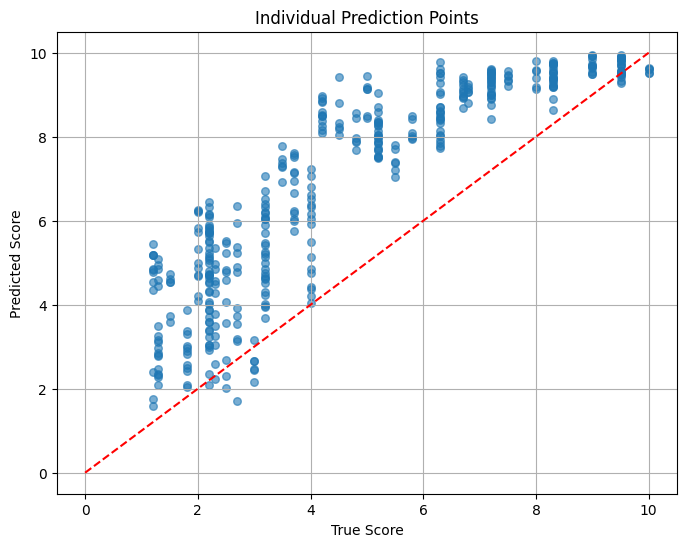

: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot every individual prediction (no panel averaging).
plt.scatter(
    results_df["TrueLabel"],
    results_df["Prediction"],
    alpha=0.6,
    s=30,
)

plt.plot([0, 10], [0, 10], "r--")

plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Individual Prediction Points")
plt.grid(True)

plt.show()

In [ ]:
#
# insight: the model is predicting greater than the true label, we will determine the best shifting
# correction and then retrain the model and see how it does. 
#

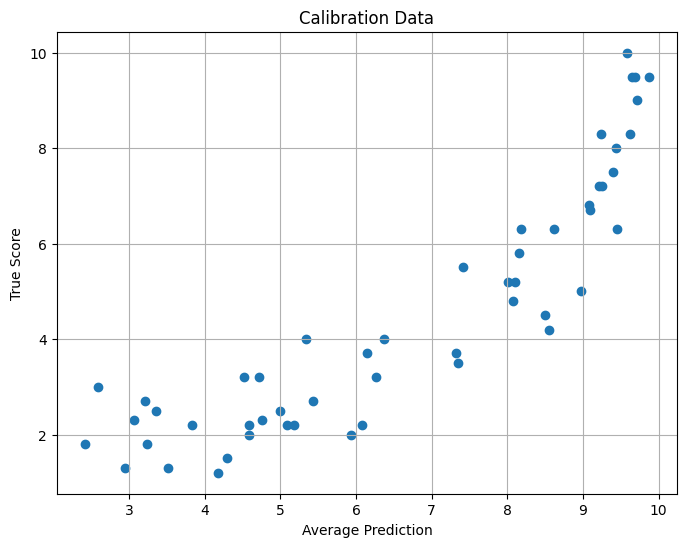

In [20]:
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

plt.figure(figsize=(8,6))
plt.scatter(x, y)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Calibration Data")

plt.grid(True)
plt.show()

In [ ]:
#
# isight: we need to find a function that takes the average prediction and outputs the 
# true score. we will look at isotonic function. 
#

In [21]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

iso = IsotonicRegression()

iso.fit(x, y)

y_iso = iso.predict(x)

print(
    "Isotonic MAE:",
    mean_absolute_error(y, y_iso)
)

Isotonic MAE: 0.43980770661280705


In [ ]:
#
# insight: isotonic function appears to perform well, so we will look at model performance
# using this isotonic correction
#

In [23]:
# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

# ⚠️ TRAINING DATA - STANDARDS ONLY
X_train_list, y_train, _ = prepare_data_with_groups(data_standards)

# ⚠️ TEST DATA - REAL PAINT (NOT used in training)
X_test_list, y_test, groups_test = prepare_data_with_groups(data_real_paint)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)

# Fit calibration function
iso = IsotonicRegression()

iso.fit(
    panel_summary["AvgPrediction"],
    panel_summary["AvgTrueLabel"]
)

# Apply calibration to every image prediction
results_df["CalibratedPrediction"] = iso.predict(
    results_df["Prediction"]
)

print("\nPredictions for each image:")
print(results_df.to_string(index=False))




Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 0.3335
Epoch 4/10 - Loss: 3.5746
Epoch 6/10 - Loss: 1.3886
Epoch 8/10 - Loss: 0.1066
Epoch 10/10 - Loss: 1.7944

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Predictions for each image:
PanelID  Prediction  TrueLabel  CalibratedPrediction
 25-130    3.115250        1.3              1.980000
 25-130    2.801412        1.3              1.980000
 25-130    2.098867        1.3                   NaN
 25-130    2.960623        1.3              1.980000
 25-130    3.487971        1.3              1.980000
 25-130    3.170682        1.3              1.980000
 25-101    5.633572        2.2              2.725000
 25-101    4.697718        2.2              2.477578
 25-101    5.515112        2.2              2.725000
 25-101    4.537925        2.2       

In [24]:
abs_error_cal = np.abs(
    results_df["TrueLabel"]
    - results_df["CalibratedPrediction"]
)

mae_cal = np.mean(abs_error_cal)

w1_cal = np.mean(abs_error_cal <= 1) * 100
w2_cal = np.mean(abs_error_cal <= 2) * 100
w3_cal = np.mean(abs_error_cal <= 3) * 100
w4_cal = np.mean(abs_error_cal <= 4) * 100

In [25]:
print("\n" + "="*60)
print("RAW MODEL PERFORMANCE")
print("="*60)

print(f"MAE: {mae:.3f}")
print(f"Within ±1: {w1:.1f}%")
print(f"Within ±2: {w2:.1f}%")
print(f"Within ±3: {w3:.1f}%")
print(f"Within ±4: {w4:.1f}%")

print("\n" + "="*60)
print("ISOTONIC CALIBRATED PERFORMANCE")
print("="*60)

print(f"MAE: {mae_cal:.3f}")
print(f"Within ±1: {w1_cal:.1f}%")
print(f"Within ±2: {w2_cal:.1f}%")
print(f"Within ±3: {w3_cal:.1f}%")
print(f"Within ±4: {w4_cal:.1f}%")


RAW MODEL PERFORMANCE
MAE: 2.094
Within ±1: 22.3%
Within ±2: 45.3%
Within ±3: 74.7%
Within ±4: 94.7%

ISOTONIC CALIBRATED PERFORMANCE
MAE: 0.722
Within ±1: 64.9%
Within ±2: 90.2%
Within ±3: 93.5%
Within ±4: 93.7%


In [27]:
from itertools import combinations
import numpy as np

def c_index(truth, pred):

    concordant = 0
    discordant = 0
    ties = 0

    for i, j in combinations(range(len(truth)), 2):

        true_diff = truth[i] - truth[j]
        pred_diff = pred[i] - pred[j]

        if true_diff == 0:
            continue

        if pred_diff == 0:
            ties += 1

        elif np.sign(true_diff) == np.sign(pred_diff):
            concordant += 1

        else:
            discordant += 1

    return (
        concordant + 0.5 * ties
    ) / (
        concordant + discordant + ties
    )

c_raw = c_index(
    panel_summary["AvgTrueLabel"].values,
    panel_summary["AvgPrediction"].values
)

print(f"Raw C-index: {c_raw:.4f}")

panel_summary["CalibratedPrediction"] = iso.predict(
    panel_summary["AvgPrediction"]
)

c_iso = c_index(
    panel_summary["AvgTrueLabel"].values,
    panel_summary["CalibratedPrediction"].values
)

print(f"Isotonic C-index: {c_iso:.4f}")

Raw C-index: 0.8843
Isotonic C-index: 0.9043


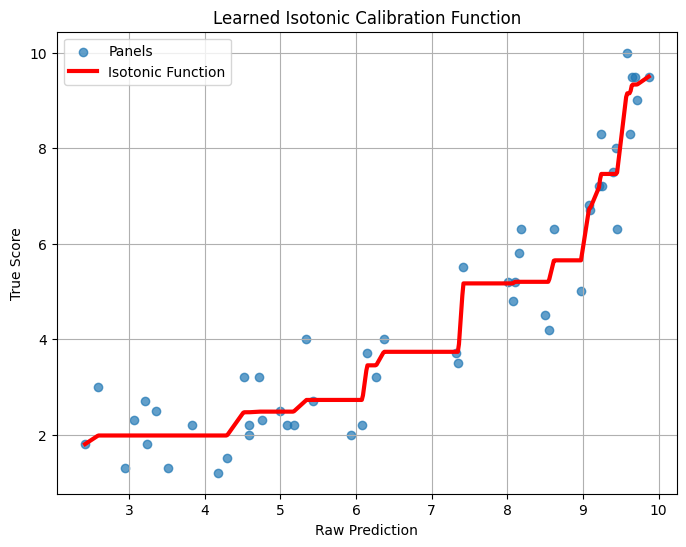

In [28]:
xs = np.linspace(
    panel_summary["AvgPrediction"].min(),
    panel_summary["AvgPrediction"].max(),
    500
)

plt.figure(figsize=(8,6))

plt.scatter(
    panel_summary["AvgPrediction"],
    panel_summary["AvgTrueLabel"],
    alpha=0.7,
    label="Panels"
)

plt.plot(
    xs,
    iso.predict(xs),
    color="red",
    linewidth=3,
    label="Isotonic Function"
)

plt.xlabel("Raw Prediction")
plt.ylabel("True Score")
plt.title("Learned Isotonic Calibration Function")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# 
# lets look at model nonlinear function instead and compare to isotonic
#

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/10 - Loss: 0.3335
Epoch 4/10 - Loss: 3.5746
Epoch 6/10 - Loss: 1.3886
Epoch 8/10 - Loss: 0.1066
Epoch 10/10 - Loss: 1.7944

Training complete!

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Quadratic Calibration Function
TrueScore = 0.195752*Prediction^2 + -1.556669*Prediction + 5.131583

QUADRATIC CALIBRATION PERFORMANCE
MAE: 0.720
Within ±1: 74.4%
Within ±2: 97.0%
Within ±3: 99.8%
Within ±4: 100.0%


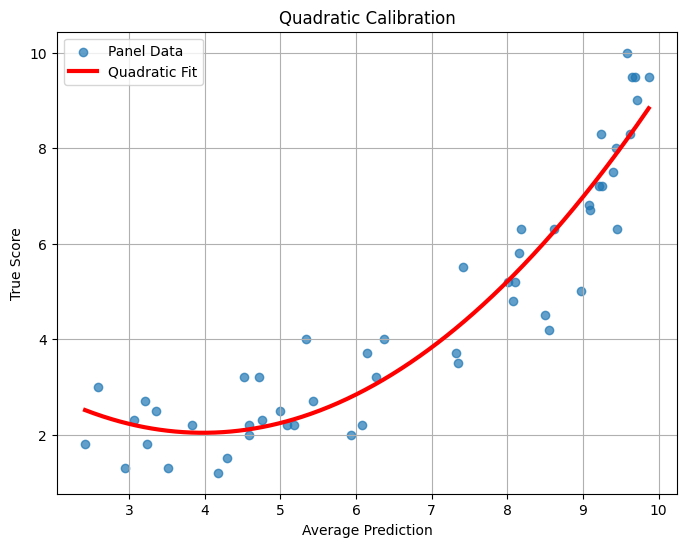

In [29]:
# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

# ⚠️ TRAINING DATA - STANDARDS ONLY
X_train_list, y_train, _ = prepare_data_with_groups(data_standards)

# ⚠️ TEST DATA - REAL PAINT (NOT used in training)
X_test_list, y_test, groups_test = prepare_data_with_groups(data_real_paint)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# print the c-index using the quadratic calibration

In [31]:
from itertools import combinations
import numpy as np

def c_index(truth, pred):

    concordant = 0
    discordant = 0
    ties = 0

    for i, j in combinations(range(len(truth)), 2):

        true_diff = truth[i] - truth[j]
        pred_diff = pred[i] - pred[j]

        if true_diff == 0:
            continue

        if pred_diff == 0:
            ties += 1

        elif np.sign(true_diff) == np.sign(pred_diff):
            concordant += 1

        else:
            discordant += 1

    return (
        concordant + 0.5 * ties
    ) / (
        concordant + discordant + ties
    )

panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean"),
        AvgQuadraticPrediction=("QuadraticPrediction", "mean")
    )
)

c_raw = c_index(
    panel_summary["AvgTrueLabel"].values,
    panel_summary["AvgPrediction"].values
)

c_quad = c_index(
    panel_summary["AvgTrueLabel"].values,
    panel_summary["AvgQuadraticPrediction"].values
)

print(f"Raw C-index:       {c_raw:.4f}")
print(f"Quadratic C-index: {c_quad:.4f}")


Raw C-index:       0.8843
Quadratic C-index: 0.8719


In [ ]:
#
# insight: the quadtaric calibration performs better for the +- metrics, but slightly worse
# than isotonic calibration for the c-index. 
#

In [ ]:
#
# lets print loss curves for the model
#

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 1/200 | Train Loss: 1.9684 | Val Loss: 3.7639
Epoch 2/200 - Loss: 1.9805
Epoch 2/200 | Train Loss: 1.9805 | Val Loss: 2.7799
Epoch 3/200 | Train Loss: 2.2740 | Val Loss: 2.8235
Epoch 4/200 - Loss: 2.3683
Epoch 4/200 | Train Loss: 2.3683 | Val Loss: 3.7288
Epoch 5/200 | Train Loss: 1.4874 | Val Loss: 1.7977
Epoch 6/200 - Loss: 0.9408
Epoch 6/200 | Train Loss: 0.9408 | Val Loss: 1.0288
Epoch 7/200 | Train Loss: 1.1087 | Val Loss: 1.0016
Epoch 8/200 - Loss: 1.2345
Epoch 8/200 | Train Loss: 1.2345 | Val Loss: 1.0569
Epoch 9/200 | Train Loss: 1.1217 | Val Loss: 0.6789
Epoch 10/200 - Loss: 1.2788
Epoch 10/200 | Train Loss: 1.2788 | Val Loss: 0.6583
Epoch 11/200 | Train Loss: 1.5133 | Val Loss: 0.6218
Epoch 12/200 - Loss: 0.6203
Epoch 12/200 | Train Loss: 0.6203 | Val Loss: 1.5136
Epoch 13/200 | Train Loss: 1.3389 | Val Loss: 1.2

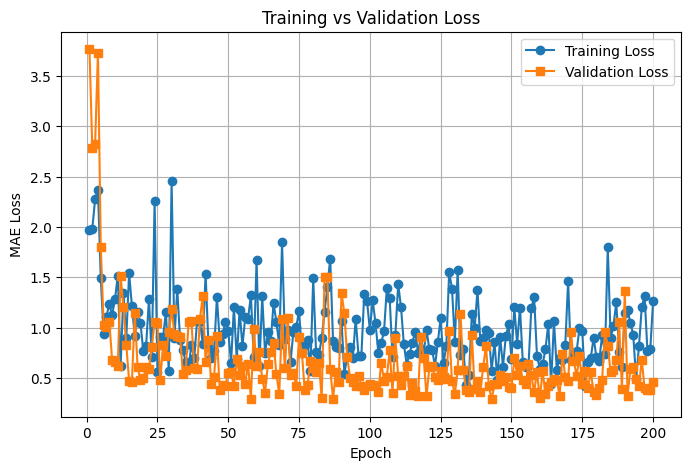

Best Validation Loss: 0.2883
Best Epoch: 143

TESTING ON ALL REAL PAINT IMAGES
Test data: 430 real paint images
Predictions shape: (430,)

Quadratic Calibration Function
TrueScore = 0.049816*Prediction^2 + 0.457008*Prediction + 0.435620

QUADRATIC CALIBRATION PERFORMANCE
MAE: 0.693
Within ±1: 74.0%
Within ±2: 97.7%
Within ±3: 100.0%
Within ±4: 100.0%


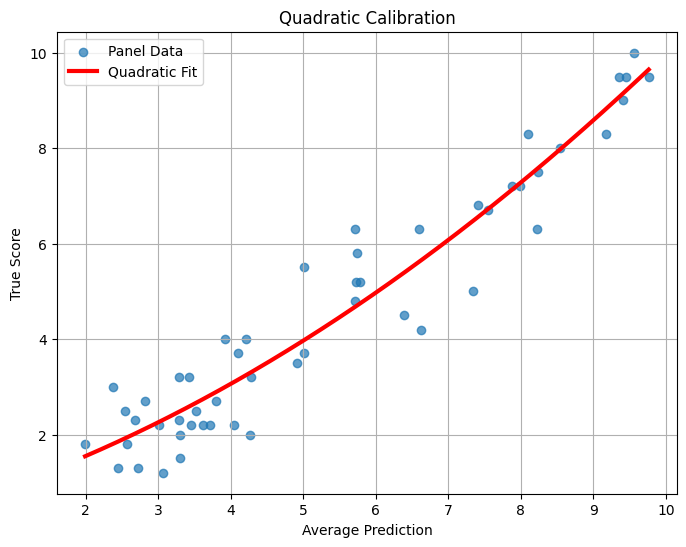

In [35]:
# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

# ⚠️ TRAINING DATA - STANDARDS ONLY
X_train_list, y_train, _ = prepare_data_with_groups(data_standards)

# ⚠️ TEST DATA - REAL PAINT (NOT used in training)
X_test_list, y_test, groups_test = prepare_data_with_groups(data_real_paint)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 200

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

train_losses = []
val_losses = []

from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    np.arange(len(X_train_list)),
    test_size=0.2,
    random_state=42
)

X_train_actual = [X_train_list[i] for i in train_idx]
y_train_actual = y_train[train_idx]

X_val = [X_train_list[i] for i in val_idx]
y_val = y_train[val_idx]

sampler = get_weighted_sampler(y_train_actual)

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_actual[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train_actual[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")
    
    train_losses.append(loss.item())

    net.eval()

    with torch.no_grad():

        val_imgs = torch.stack([
            test_transform(img)
            for img in X_val
        ]).to(device)

        val_labels = torch.tensor(
            y_val,
            dtype=torch.float32
        ).to(device)

        val_outputs = net(val_imgs).squeeze(1)

        val_loss = criterion(
            val_outputs,
            val_labels
        )

    val_losses.append(val_loss.item())

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {loss.item():.4f} | "
        f"Val Loss: {val_loss.item():.4f}"
    )

print(f"\nTraining complete!")
plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    train_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    range(1, epochs+1),
    val_losses,
    marker='s',
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

print(f"Best Validation Loss: {min(val_losses):.4f}")
print(f"Best Epoch: {np.argmin(val_losses)+1}")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#
# insight: determined that the best epoch is 143, so we will train the model for that
# many epochs and see the performance
#

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/143 - Loss: 0.3335
Epoch 4/143 - Loss: 3.5746
Epoch 6/143 - Loss: 1.3886
Epoch 8/143 - Loss: 0.1066
Epoch 10/143 - Loss: 1.7944
Epoch 12/143 - Loss: 4.0808
Epoch 14/143 - Loss: 4.0501
Epoch 16/143 - Loss: 2.3275
Epoch 18/143 - Loss: 6.1895
Epoch 20/143 - Loss: 0.0839
Epoch 22/143 - Loss: 2.5250
Epoch 24/143 - Loss: 1.0184
Epoch 26/143 - Loss: 1.7342
Epoch 28/143 - Loss: 1.1838
Epoch 30/143 - Loss: 0.9122
Epoch 32/143 - Loss: 1.2945
Epoch 34/143 - Loss: 2.8980
Epoch 36/143 - Loss: 0.8793
Epoch 38/143 - Loss: 1.1639
Epoch 40/143 - Loss: 1.6303
Epoch 42/143 - Loss: 2.1278
Epoch 44/143 - Loss: 0.8237
Epoch 46/143 - Loss: 3.7547
Epoch 48/143 - Loss: 1.0231
Epoch 50/143 - Loss: 2.5901
Epoch 52/143 - Loss: 1.8429
Epoch 54/143 - Loss: 2.0406
Epoch 56/143 - Loss: 0.9064
Epoch 58/143 - Loss: 1.9663
Epoch 60/143 - Loss: 3.1111
Epoc

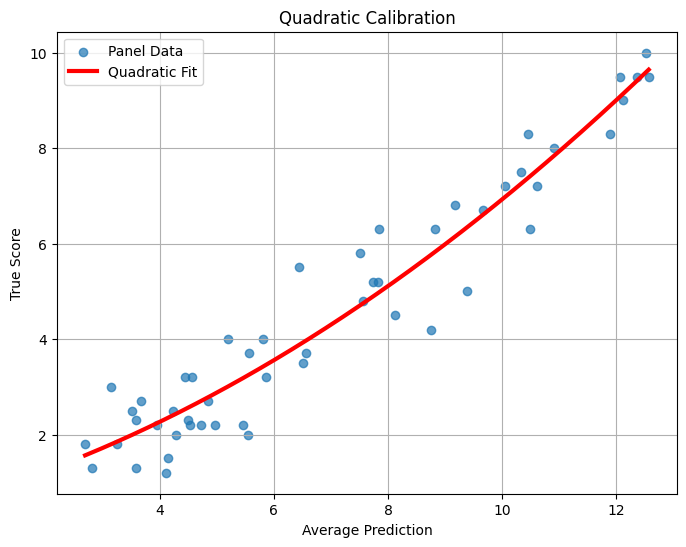

In [36]:
# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

# ⚠️ TRAINING DATA - STANDARDS ONLY
X_train_list, y_train, _ = prepare_data_with_groups(data_standards)

# ⚠️ TEST DATA - REAL PAINT (NOT used in training)
X_test_list, y_test, groups_test = prepare_data_with_groups(data_real_paint)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 143

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))

In [37]:
# now lets report the c-index 

from itertools import combinations
import numpy as np

def c_index(truth, pred):

    concordant = 0
    discordant = 0
    ties = 0

    for i, j in combinations(range(len(truth)), 2):

        true_diff = truth[i] - truth[j]
        pred_diff = pred[i] - pred[j]

        if true_diff == 0:
            continue

        if pred_diff == 0:
            ties += 1

        elif np.sign(true_diff) == np.sign(pred_diff):
            concordant += 1

        else:
            discordant += 1

    return (
        concordant + 0.5 * ties
    ) / (
        concordant + discordant + ties
    )

panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean"),
        AvgQuadraticPrediction=("QuadraticPrediction", "mean")
    )
)

c_raw = c_index(
    panel_summary["AvgTrueLabel"].values,
    panel_summary["AvgPrediction"].values
)

c_quad = c_index(
    panel_summary["AvgTrueLabel"].values,
    panel_summary["AvgQuadraticPrediction"].values
)

print(f"Raw C-index:       {c_raw:.4f}")
print(f"Quadratic C-index: {c_quad:.4f}")


Raw C-index:       0.8897
Quadratic C-index: 0.8889


In [ ]:
#
# insight: the quadratic calibration appears to perform well, we can see that the calibration 
# helps us go back to the scale humans are used to and it is able to get the order correct
# from what the humans said 88% of the time. 
#

In [ ]:
# now lets look at the original model traine on standards and real paint and 
# see what the c-index is

In [5]:
# current best model with the new data added (data_new_2) mae results reported after 10 epochs
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split, GroupKFold
from collections import Counter, defaultdict

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

X_real, y_real, groups_real = prepare_data_with_groups(data_real_paint)
X_std, y_std, _ = prepare_data_with_groups(data_standards)

# =========================
# ✅ PANEL SPLIT
# =========================
unique_panels = np.unique(groups_real)

train_panels, test_panels = train_test_split(
    unique_panels, test_size=0.2, random_state=42
)

train_idx = np.isin(groups_real, train_panels)
test_idx  = np.isin(groups_real, test_panels)

X_train_real = [X_real[i] for i in range(len(X_real)) if train_idx[i]]
y_train_real = y_real[train_idx]
groups_train = groups_real[train_idx]

X_test = [X_real[i] for i in range(len(X_real)) if test_idx[i]]
y_test = y_real[test_idx]
groups_test = groups_real[test_idx]

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ CROSS VALIDATION
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 10

gkf = GroupKFold(n_splits=5)

cv_maes = []
cv_val_losses = []   # ✅ NEW

for fold, (train_idx_cv, val_idx_cv) in enumerate(
    gkf.split(X_train_real, y_train_real, groups_train)
):
    print(f"\n===== Fold {fold+1} =====")

    X_train_fold = [X_train_real[i] for i in train_idx_cv] + X_std
    y_train_fold = np.concatenate([y_train_real[train_idx_cv], y_std])

    X_val_fold = [X_train_real[i] for i in val_idx_cv]
    y_val_fold = y_train_real[val_idx_cv]

    sampler = get_weighted_sampler(y_train_fold)

    net = WaveletCNN().to(device)
    optimizer = optim.Adam(net.parameters(), lr=5e-4)
    criterion = nn.L1Loss()

    best_mae = float("inf")
    best_val_loss = float("inf")   # ✅ NEW

    for epoch in range(epochs):
        net.train()

        idx_list = list(sampler)

        for i in range(0, len(idx_list), batch_size):
            idx = idx_list[i:i+batch_size]

            imgs = torch.stack([
                train_transform(X_train_fold[j]) for j in idx
            ]).to(device)

            labels = torch.tensor(y_train_fold[idx]).float().to(device)

            optimizer.zero_grad()
            outputs = net(imgs).squeeze()

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # ✅ VALIDATION
        net.eval()
        X_val_proc = torch.stack(
            [test_transform(img) for img in X_val_fold]
        ).to(device)

        with torch.no_grad():
            outputs = net(X_val_proc).squeeze()
            preds = outputs.cpu().numpy()

        mae = np.mean(np.abs(y_val_fold - preds))

        labels = torch.tensor(y_val_fold).float().to(device)
        val_loss = criterion(outputs, labels).item()

# after epoch 10 finishes, mae and val_loss
# are the values from the LAST epoch

    print(f"Fold {fold+1} MAE (Epoch {epochs}): {mae:.3f}")

    cv_maes.append(mae)
    cv_val_losses.append(val_loss)

print("\nCV Mean MAE:", np.mean(cv_maes))
print("CV Mean Val Loss:", np.mean(cv_val_losses))   # ✅ NEW

# =========================
# ✅ FINAL TRAIN + TEST
# =========================
print("\n===== FINAL TRAIN + TEST =====")

X_train = X_train_real + X_std
y_train = np.concatenate([y_train_real, y_std])

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# ✅ TEST
net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

abs_error = np.abs(y_test - preds)

mae = np.mean(abs_error)
w1 = np.mean(abs_error <= 1) * 100
w2 = np.mean(abs_error <= 2) * 100

print(f"\nTEST → MAE={mae:.3f}, ±1={w1:.1f}%, ±2={w2:.1f}%")

# =========================
# ✅ CONSISTENCY METRIC
# =========================
panel_preds = defaultdict(list)

for pred, panel in zip(preds, groups_test):
    panel_preds[panel].append(pred)

stds = []

for panel in panel_preds:
    vals = np.array(panel_preds[panel])
    if len(vals) > 1:
        stds.append(np.std(vals))

mean_std = np.mean(stds)

print(f"Mean per-panel std: {mean_std:.3f}")


===== Fold 1 =====
Fold 1 MAE (Epoch 10): 0.516

===== Fold 2 =====
Fold 2 MAE (Epoch 10): 1.061

===== Fold 3 =====
Fold 3 MAE (Epoch 10): 0.677

===== Fold 4 =====
Fold 4 MAE (Epoch 10): 0.694

===== Fold 5 =====
Fold 5 MAE (Epoch 10): 1.250

CV Mean MAE: 0.8395095520265616
CV Mean Val Loss: 0.8395095229148865

===== FINAL TRAIN + TEST =====

TEST → MAE=0.753, ±1=68.3%, ±2=100.0%
Mean per-panel std: 0.309


In [9]:
# report c-index

from itertools import combinations
import numpy as np
import pandas as pd

def c_index(truth, pred):

    concordant = 0
    discordant = 0
    ties = 0

    for i, j in combinations(range(len(truth)), 2):

        true_diff = truth[i] - truth[j]
        pred_diff = pred[i] - pred[j]

        if true_diff == 0:
            continue

        if pred_diff == 0:
            ties += 1

        elif np.sign(true_diff) == np.sign(pred_diff):
            concordant += 1

        else:
            discordant += 1

    return (
        concordant + 0.5 * ties
    ) / (
        concordant + discordant + ties
    )

# =========================
# ✅ PANEL-LEVEL C-INDEX
# =========================

panel_pred_mean = defaultdict(list)
panel_true = {}

for pred, true, panel in zip(preds, y_test, groups_test):

    panel_pred_mean[panel].append(pred)
    panel_true[panel] = true

panel_names = sorted(panel_pred_mean.keys())

panel_avg_pred = np.array([
    np.mean(panel_pred_mean[p])
    for p in panel_names
])

panel_true_scores = np.array([
    panel_true[p]
    for p in panel_names
])

cidx = c_index(
    panel_true_scores,
    panel_avg_pred
)

print("\n" + "="*60)
print("PANEL LEVEL C-INDEX")
print("="*60)
print(f"C-index: {cidx:.4f}")

# =========================
# ✅ TEST PANELS + TRUE SCORES
# =========================

test_panel_df = pd.DataFrame({
    "PanelID": groups_test,
    "TrueScore": y_test
})

# One row per panel
test_panel_df = test_panel_df.drop_duplicates()

# Sort by true score
test_panel_df = test_panel_df.sort_values(
    "TrueScore"
)

print("\n" + "="*60)
print("TEST SET PANELS")
print("="*60)

print(test_panel_df.to_string(index=False))


PANEL LEVEL C-INDEX
C-index: 0.9245

TEST SET PANELS
PanelID  TrueScore
 25-112        1.8
 25-117        2.2
 25-103        2.5
 25-113        2.5
 25-119        4.0
 25-150        5.0
 25-143        5.8
 25-141        6.3
 25-132        6.7
 25-105        8.3
 25-147        8.3


In [ ]:
#
# insight: although the model trained on standards and real paint and tested on real paint performed the best looking at the metrics, 
# The model trained only on the standards has no human noise in the labeling so this might be the better model to choose as its trained on correct labels and 
# The decrease in performance may just due to being tested on noisy labels, bradley agrees with this
# The current best model we have found then is train only on standards and use the quadratic calibration,
# below is the best current model with the quadratic calibration
#

In [10]:
# current best model (trained only on standards)

# Model trained only on standards, tested on real paint
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from collections import Counter, defaultdict
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)

# =========================
# ✅ DATA PREP
# =========================
def prepare_data_with_groups(data, img_size=(128, 128)):
    X, y, groups = [], [], []

    for d in data:
        img = d["image"].astype(np.float32) / 255.0
        img = torch.tensor(img).unsqueeze(0)

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0), size=img_size,
            mode="bilinear", align_corners=False
        ).squeeze(0)

        X.append(img)
        y.append(d["LevelingScore"])
        groups.append(d.get("PanelID", None))

    return X, np.array(y), np.array(groups)

# ⚠️ TRAINING DATA - STANDARDS ONLY
X_train_list, y_train, _ = prepare_data_with_groups(data_standards)

# ⚠️ TEST DATA - REAL PAINT (NOT used in training)
X_test_list, y_test, groups_test = prepare_data_with_groups(data_real_paint)

print(f"Training dataset: {len(X_train_list)} standard images (NOT using real paint)")
print(f"Test dataset: {len(X_test_list)} real paint images\n")

# =========================
# ✅ TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.RandomResizedCrop(128, scale=(0.95, 1.0)),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# =========================
# ✅ MODEL
# =========================
class WaveletCNN(nn.Module):
    def __init__(self, num_blocks=5, base_channels=16):
        super().__init__()

        self.pool = nn.AvgPool2d(2)

        layers = []
        in_channels = 1
        channels = base_channels

        for i in range(num_blocks):
            layers += [
                nn.Conv2d(in_channels, channels, 3, padding=1),
                nn.BatchNorm2d(channels),
                nn.ReLU(),
                nn.Conv2d(channels, channels, 3, padding=1),
                nn.ReLU()
            ]

            if i < num_blocks - 1:
                layers.append(nn.MaxPool2d(2))

            in_channels = channels
            channels *= 2

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        self.features = nn.Sequential(*layers)

        self.regressor = nn.Sequential(
            nn.Linear(in_channels + 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x_low1 = self.pool(x)
        x_low2 = self.pool(x_low1)

        m0 = x.mean(dim=[2,3])
        m1 = x_low1.mean(dim=[2,3])
        m2 = x_low2.mean(dim=[2,3])

        wavelet_feats = torch.cat([m0, m1, m2], dim=1)

        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        combined = torch.cat([feats, wavelet_feats], dim=1)

        return self.regressor(combined)

# =========================
# ✅ SAMPLER
# =========================
def get_weighted_sampler(y):
    counter = Counter(y)
    weights = np.array([1.0 / counter[val] for val in y])
    return torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(weights, dtype=torch.float),
        num_samples=len(weights),
        replacement=True
    )

# =========================
# ✅ TRAIN ONLY ON STANDARDS
# =========================
print("="*60)
print("TRAINING ONLY ON STANDARDS")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 16
epochs = 143

sampler = get_weighted_sampler(y_train)

net = WaveletCNN().to(device)
optimizer = optim.Adam(net.parameters(), lr=5e-4)
criterion = nn.L1Loss()

print(f"Training data: {len(X_train_list)} standard images")

for epoch in range(epochs):
    net.train()

    idx_list = list(sampler)

    for i in range(0, len(idx_list), batch_size):
        idx = idx_list[i:i+batch_size]

        imgs = torch.stack([
            train_transform(X_train_list[j]) for j in idx
        ]).to(device)

        labels = torch.tensor(y_train[idx]).float().to(device)

        optimizer.zero_grad()
        outputs = net(imgs).squeeze(1)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

print(f"\nTraining complete!")

# =========================
# ✅ TEST ON ALL REAL PAINT
# =========================
print("\n" + "="*60)
print("TESTING ON ALL REAL PAINT IMAGES")
print("="*60)

net.eval()

X_test_proc = torch.stack(
    [test_transform(img) for img in X_test_list]
).to(device)

with torch.no_grad():
    preds = net(X_test_proc).squeeze().cpu().numpy()

# Ensure preds is 1D
if preds.ndim == 0:
    preds = np.array([preds])

print(f"Test data: {len(X_test_list)} real paint images")
print(f"Predictions shape: {preds.shape}")

# =========================
# ✅ OUTPUT RESULTS
# =========================
results_df = pd.DataFrame({
    'PanelID': groups_test,
    'Prediction': preds,
    'TrueLabel': y_test
})

from sklearn.isotonic import IsotonicRegression

# Panel-level calibration data
panel_summary = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        AvgTrueLabel=("TrueLabel", "mean")
    )
)
from sklearn.metrics import mean_absolute_error

# x = raw model predictions
# y = human scores

x = panel_summary["AvgPrediction"].values
y = panel_summary["AvgTrueLabel"].values

# Fit quadratic
quad_coeffs = np.polyfit(x, y, 2)

a, b, c = quad_coeffs

print("\nQuadratic Calibration Function")
print(
    f"TrueScore = "
    f"{a:.6f}*Prediction^2 + "
    f"{b:.6f}*Prediction + "
    f"{c:.6f}"
)

results_df["QuadraticPrediction"] = (
    a * results_df["Prediction"]**2
    + b * results_df["Prediction"]
    + c
)

abs_error_quad = np.abs(
    results_df["TrueLabel"]
    - results_df["QuadraticPrediction"]
)

mae_quad = np.mean(abs_error_quad)

w1_quad = np.mean(abs_error_quad <= 1) * 100
w2_quad = np.mean(abs_error_quad <= 2) * 100
w3_quad = np.mean(abs_error_quad <= 3) * 100
w4_quad = np.mean(abs_error_quad <= 4) * 100

print("\n" + "="*60)
print("QUADRATIC CALIBRATION PERFORMANCE")
print("="*60)

print(f"MAE: {mae_quad:.3f}")
print(f"Within ±1: {w1_quad:.1f}%")
print(f"Within ±2: {w2_quad:.1f}%")
print(f"Within ±3: {w3_quad:.1f}%")
print(f"Within ±4: {w4_quad:.1f}%")

xs = np.linspace(x.min(), x.max(), 500)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(x, y, alpha=0.7, label="Panel Data")

plt.plot(
    xs,
    a*xs**2 + b*xs + c,
    color="red",
    linewidth=3,
    label="Quadratic Fit"
)

plt.xlabel("Average Prediction")
plt.ylabel("True Score")
plt.title("Quadratic Calibration")
plt.legend()
plt.grid(True)
plt.show()

import numpy as np

panel_stats = (
    results_df
    .groupby("PanelID")
    .agg(
        AvgPrediction=("Prediction", "mean"),
        PredictionStd=("Prediction", "std"),
        TrueScore=("TrueLabel", "first"),
        N=("Prediction", "count")
    )
    .reset_index()
    .sort_values("PredictionStd", ascending=False)
)

print(panel_stats.to_string(index=False))

Training dataset: 177 standard images (NOT using real paint)
Test dataset: 430 real paint images

TRAINING ONLY ON STANDARDS
Training data: 177 standard images
Epoch 2/143 - Loss: 0.3335
Epoch 4/143 - Loss: 3.5746
Epoch 6/143 - Loss: 1.3886
Epoch 8/143 - Loss: 0.1066
Epoch 10/143 - Loss: 1.7944
Epoch 12/143 - Loss: 4.0808
Epoch 14/143 - Loss: 4.0501
Epoch 16/143 - Loss: 2.3275
Epoch 18/143 - Loss: 6.1895
Epoch 20/143 - Loss: 0.0839
Epoch 22/143 - Loss: 2.5250
Epoch 24/143 - Loss: 1.0184
Epoch 26/143 - Loss: 1.7342
Epoch 28/143 - Loss: 1.1838
Epoch 30/143 - Loss: 0.9122
Epoch 32/143 - Loss: 1.2945
Epoch 34/143 - Loss: 2.8980
Epoch 36/143 - Loss: 0.8793
Epoch 38/143 - Loss: 1.1639
Epoch 40/143 - Loss: 1.6303
Epoch 42/143 - Loss: 2.1278
Epoch 44/143 - Loss: 0.8237
Epoch 46/143 - Loss: 3.7547
Epoch 48/143 - Loss: 1.0231
Epoch 50/143 - Loss: 2.5901
Epoch 52/143 - Loss: 1.8429
Epoch 54/143 - Loss: 2.0406
Epoch 56/143 - Loss: 0.9064
Epoch 58/143 - Loss: 1.9663
Epoch 60/143 - Loss: 3.1111
Epoc

NameError: name 'plt' is not defined